# 01. Exploratory Data Analysis (EDA)
In this notebook, we perform data exploration on the water consumption dataset to identify trends, seasonal effects, and potential anomalies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 1. Load Data
We start by loading the dataset and parsing the dates.

In [2]:
df = pd.read_csv("../Dataset/raw/water_consumption_forecasting.csv")
df["date"] = pd.to_datetime(df["date"])
display(df.head())
print(f"Dataset shape: {df.shape}")

,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58


Dataset shape: (900, 3)


## 2. Summary Statistics & Data Quality
Check for missing values and summary statistics.

In [3]:
print("Missing values:\n", df.isnull().sum())
display(df.describe())

Missing values:
 region                0
date                  0
consumption_liters    0
dtype: int64


,date,consumption_liters
count,900,900.000000
mean,2023-03-31 11:59:59.999999744,12753.758211
min,2023-01-01 00:00:00,5004.090000
25%,2023-02-14 18:00:00,9187.247500
50%,2023-03-31 12:00:00,13045.510000
75%,2023-05-15 06:00:00,16365.062500
max,2023-06-29 00:00:00,19989.830000
std,NaN,4278.566391


## 3. Visualizing Consumption Distribution
Let us see how the daily consumption is distributed overall.

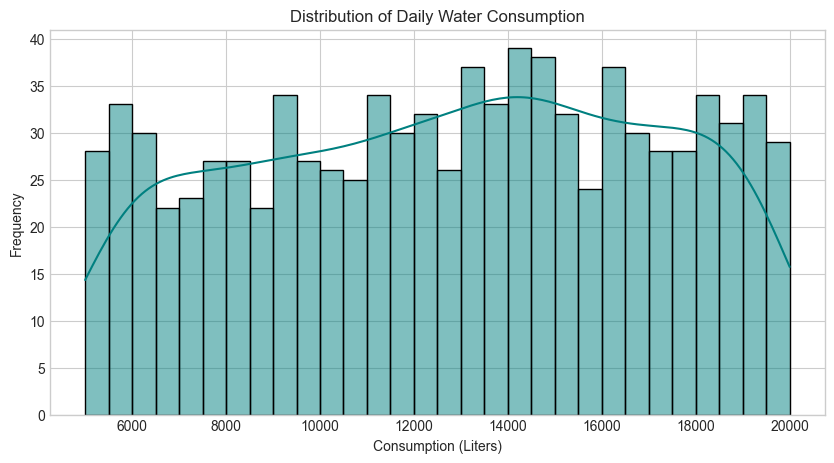

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(df["consumption_liters"], bins=30, kde=True, color="teal")
plt.title("Distribution of Daily Water Consumption")
plt.xlabel("Consumption (Liters)")
plt.ylabel("Frequency")
plt.show()

## 4. Regional Trends Over Time
We plot the consumption over time for each region to identify patterns.

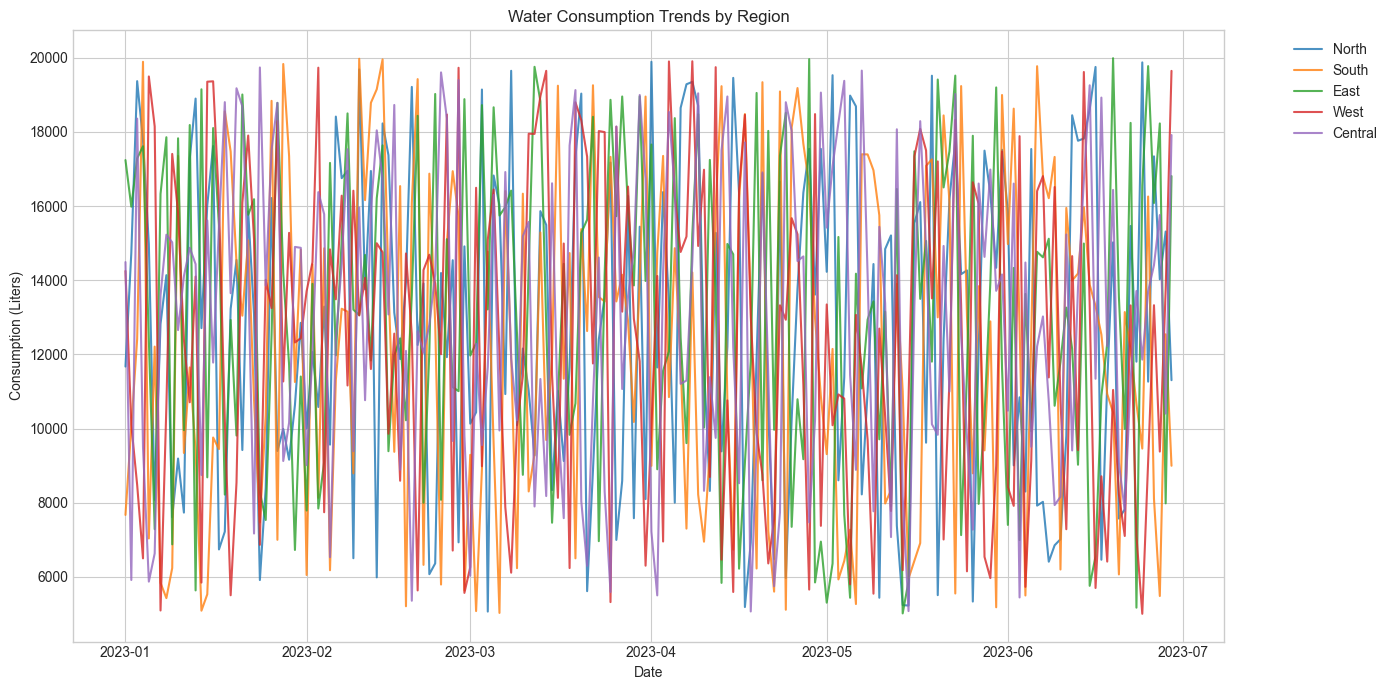

In [5]:
plt.figure(figsize=(14,7))
sns.lineplot(data=df, x="date", y="consumption_liters", hue="region", alpha=0.8)
plt.title("Water Consumption Trends by Region")
plt.xlabel("Date")
plt.ylabel("Consumption (Liters)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Day of Week Analysis
Water usage might differ depending on the day of the week.

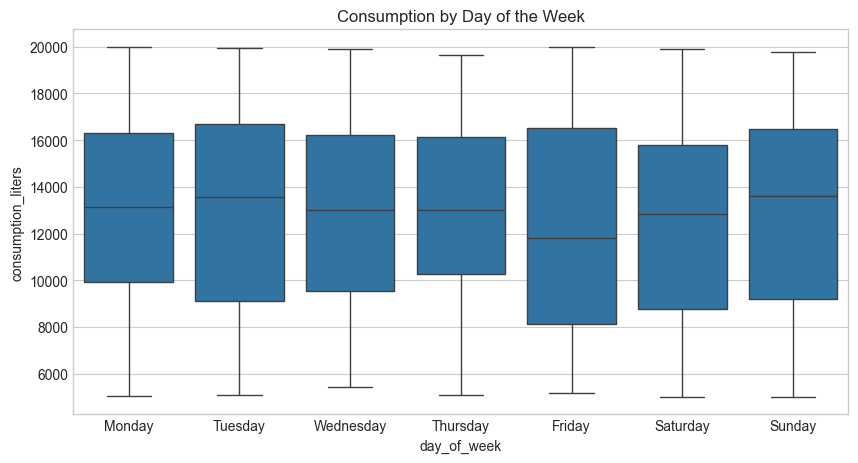

In [6]:
df["day_of_week"] = df["date"].dt.day_name()
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="day_of_week", y="consumption_liters", 
            order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Consumption by Day of the Week")
plt.show()